# Museum Visitor Analysis

This notebook explores the relationship between city population and annual museum visitor counts for the world's most-visited museums.

We pull this data from two places: we get the museum attendance directly from Wikipedia's list of most-visited museums, and we grab the corresponding city populations using Wikidata. The data pipeline handles loading everything into PostgreSQL, and we query it here to run our regression model.

## Setup

In [1]:
import logging
import os

import matplotlib.pyplot as plt
import pandas as pd

from museums.db.session import get_session
from museums.ml.regression import load_regression_data, run_regression
from museums.models.schema import City, Museum
from museums.pipeline.etl import run as run_pipeline

logging.basicConfig(level=logging.INFO)

# Inline plots
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

### Check if the database has data

We just do a quick check here to make sure the database is populated before we start querying.

In [2]:
with get_session() as session:
    museum_count = session.query(Museum).count()

if museum_count == 0:
    print("Database is empty. Running the ETL pipeline...")
    run_pipeline()
else:
    print(f"Database already contains {museum_count} museums. Skipping pipeline run.")

Database already contains 42 museums. Skipping pipeline run.


---

## 1. Data Overview

First, pull the full dataset out of the database and look at what was loaded.

In [3]:
with get_session() as session:
    rows = (
        session.query(Museum, City)
        .join(City, Museum.city_id == City.id)
        .order_by(Museum.annual_visitors.desc())
        .all()
    )

    df_all = pd.DataFrame(
        [
            {
                "museum": m.name,
                "city": c.name,
                "country": c.country,
                "annual_visitors": m.annual_visitors,
                "visitor_year": m.visitor_year,
                "city_population": c.population,
                "wikidata_qid": c.wikidata_qid,
            }
            for m, c in rows
        ]
    )

print(f"Total museums loaded: {len(df_all)}")
print(f"Unique cities: {df_all['city'].nunique()}")
print(f"Unique countries: {df_all['country'].nunique()}")
print(f"Cities with population data: {df_all['city_population'].notna().sum()} / {len(df_all)}")

df_all.head(10)

Total museums loaded: 42
Unique cities: 24
Unique countries: 17
Cities with population data: 39 / 42


,museum,city,country,annual_visitors,visitor_year,city_population,wikidata_qid
0,Louvre,Paris,France,9000000,2025,2103778.0,Q90
1,National Museum of China,Beijing,China,6956800,2024,21893095.0,Q956
2,Vatican Museums,Vatican City,Vatican,6933822,2025,882.0,Q237
3,Shenzhen Museum,Shenzhen,China,6805000,2024,17494398.0,Q15174
4,National Museum of Korea,Seoul,South Korea,6507483,2025,9668465.0,Q8684
5,British Museum,London,United Kingdom,6440120,2025,422324.0,Q92561
6,China Science and Technology Museum,Beijing,China,6421000,2024,21893095.0,Q956
7,"Natural History Museum, South Kensington",London,United Kingdom,6301972,2024,422324.0,Q92561
8,Metropolitan Museum of Art,New York City,United States,5984091,2025,8804190.0,Q60
9,Nanjing Museum,Nanjing,China,5680000,2024,9314685.0,Q16666


---

## 2. Top Museums by Annual Visitors

A ranked bar chart of all museums in the dataset. The threshold for inclusion is
2,000,000 annual visitors per the project brief.

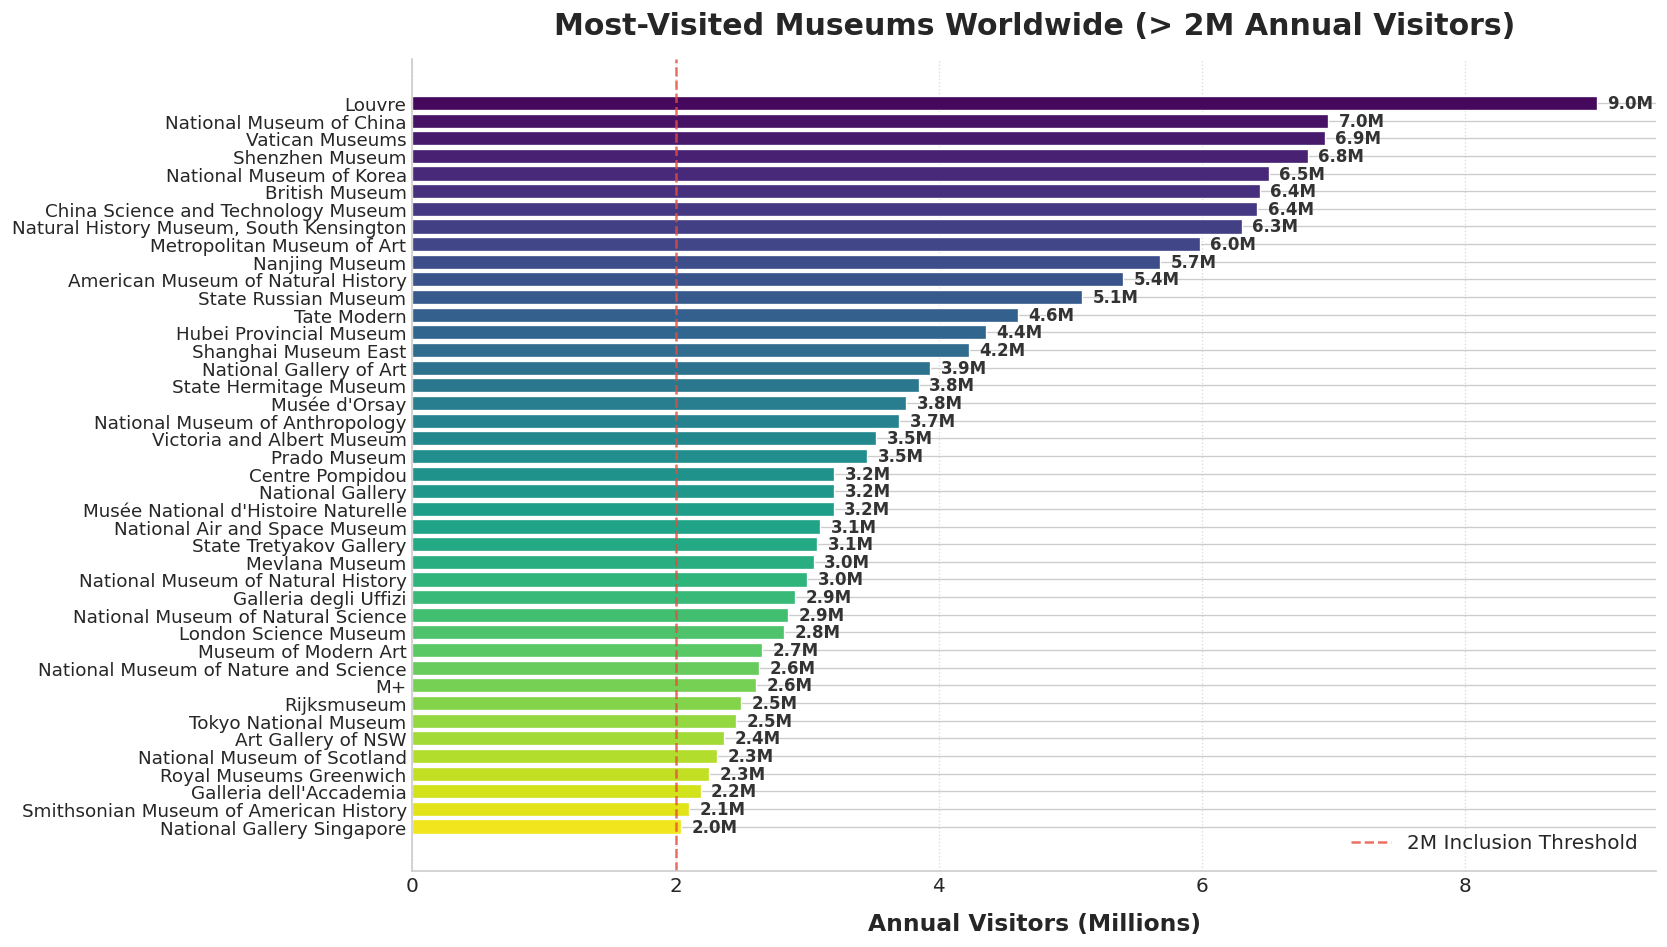

In [4]:
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, max(8, len(df_all) * 0.05)))

# Use a sophisticated color palette
colors = sns.color_palette("viridis", len(df_all))

bars = ax.barh(
    df_all["museum"],
    df_all["annual_visitors"] / 1e6,
    color=colors,
    edgecolor="white",
    linewidth=0.8,
)

# Label each bar with the visitor count.
for bar, visitors in zip(bars, df_all["annual_visitors"]):
    ax.text(
        bar.get_width() + 0.08,
        bar.get_y() + bar.get_height() / 2,
        f"{visitors / 1e6:.1f}M",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#333333"
    )

ax.set_xlabel("Annual Visitors (Millions)", fontsize=14, fontweight="bold", labelpad=10)
ax.set_title("Most-Visited Museums Worldwide (> 2M Annual Visitors)", fontsize=18, fontweight="bold", pad=15)
ax.invert_yaxis()
ax.axvline(x=2, color="#e74c3c", linestyle="--", linewidth=1.5, alpha=0.8, label="2M Inclusion Threshold")
ax.legend(fontsize=12, loc="lower right")

ax.tick_params(axis="y", which="major", labelsize=11)
ax.tick_params(axis="x", which="major", labelsize=12)
ax.grid(axis="x", linestyle=":", alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---

## 3. Museums by Country

How many museums in this list does each country have? This gives a sense of geographic
concentration.

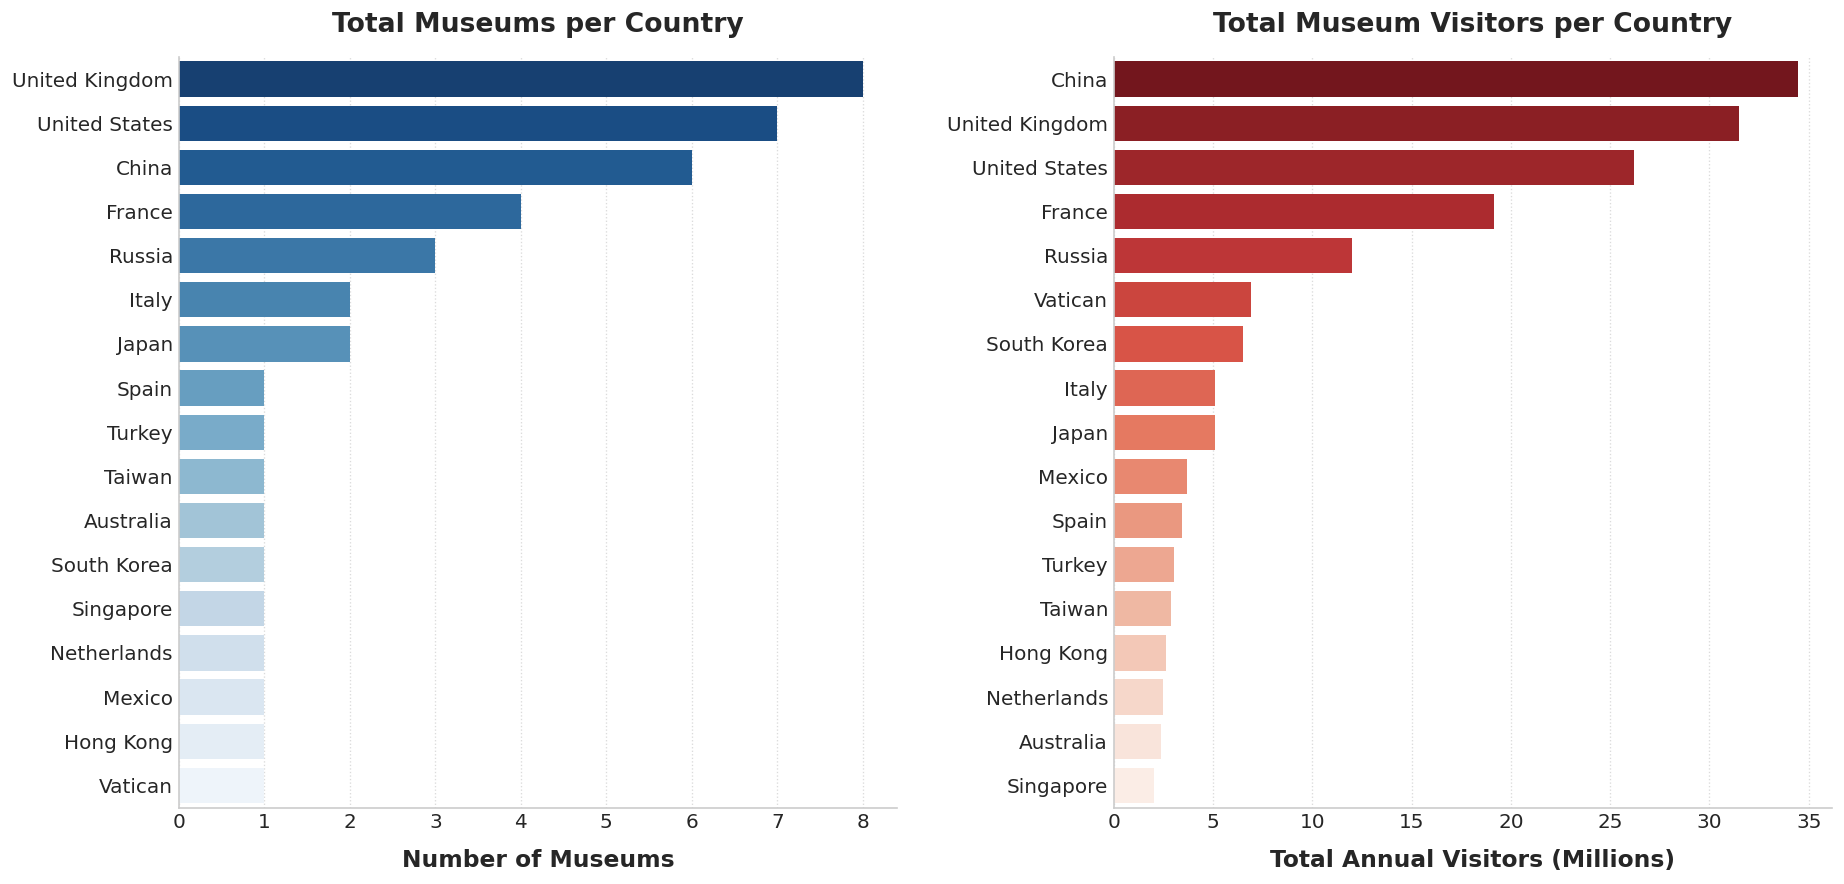

       country  museum_count  total_visitors
United Kingdom             8        31472237
 United States             7        26178011
         China             6        34449743
        France             4        19155369
        Russia             3        12009627
         Italy             2         5097931
         Japan             2         5094997
         Spain             1         3457057
        Turkey             1         3048000
        Taiwan             1         2854455
     Australia             1         2369339
   South Korea             1         6507483
     Singapore             1         2040481
   Netherlands             1         2500000
        Mexico             1         3700000
     Hong Kong             1         2610000
       Vatican             1         6933822


In [5]:
country_counts = (
    df_all.groupby("country")
    .agg(museum_count=("museum", "count"), total_visitors=("annual_visitors", "sum"))
    .sort_values("museum_count", ascending=False)
    .reset_index()
)

import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: museum count per country
sns.barplot(
    data=country_counts,
    y="country",
    x="museum_count",
    ax=axes[0],
    palette="Blues_r",
    hue="country",
    legend=False
)
axes[0].set_xlabel("Number of Museums", fontsize=14, fontweight="bold", labelpad=10)
axes[0].set_ylabel("")
axes[0].set_title("Total Museums per Country", fontsize=16, fontweight="bold", pad=15)
axes[0].tick_params(axis="both", which="major", labelsize=12)
axes[0].grid(axis="x", linestyle=":", alpha=0.7)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: total visitors per country
sns.barplot(
    data=country_counts.sort_values("total_visitors", ascending=False),
    y="country",
    x=country_counts.sort_values("total_visitors", ascending=False)["total_visitors"] / 1e6,
    ax=axes[1],
    palette="Reds_r",
    hue="country",
    legend=False
)
axes[1].set_xlabel("Total Annual Visitors (Millions)", fontsize=14, fontweight="bold", labelpad=10)
axes[1].set_ylabel("")
axes[1].set_title("Total Museum Visitors per Country", fontsize=16, fontweight="bold", pad=15)
axes[1].tick_params(axis="both", which="major", labelsize=12)
axes[1].grid(axis="x", linestyle=":", alpha=0.7)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(pad=3.0)
plt.show()

print(country_counts.to_string(index=False))

---

## 4. City Concentration

Some cities contribute many museums to this list. London and Paris are the most
concentrated. This matters for the regression: multiple museums in the same city
share the same city population value, so those cities have more weight in the model.

In [6]:
city_counts = (
    df_all.groupby(["city", "country"])
    .agg(
        museum_count=("museum", "count"),
        total_visitors=("annual_visitors", "sum"),
        city_population=("city_population", "first"),
    )
    .sort_values("museum_count", ascending=False)
    .reset_index()
)

print("Cities with more than one museum in this dataset:")
print(
    city_counts[city_counts["museum_count"] > 1]
    .to_string(index=False)
)

Cities with more than one museum in this dataset:
            city        country  museum_count  total_visitors  city_population
          London United Kingdom             7        29157263         422324.0
           Paris         France             4        19155369        2103778.0
Washington, D.C.  United States             4        12136543         689545.0
   New York City  United States             3        14041468        8804190.0
        Florence          Italy             2         5097931              NaN
           Tokyo          Japan             2         5094997        9640742.0
         Beijing          China             2        13377800       21893095.0
Saint Petersburg         Russia             2         8933651        5652922.0


---

## 5. Linear Regression: City Population vs. Museum Visitors

We fit a simple linear regression with city population as the predictor and annual
museum visitors as the target.

Each museum is one observation. Museums in cities without a resolved Wikidata population
are excluded from the regression.

In [7]:
df_regression = load_regression_data()

print(f"Museums included in regression: {len(df_regression)}")
print(f"Museums excluded (no city population): {len(df_all) - len(df_regression)}")

df_regression.describe()

INFO:museums.ml.regression:Loaded 39 museum rows for regression


Museums included in regression: 39
Museums excluded (no city population): 3


,annual_visitors,visitor_year,city_population
count,3.900000e+01,39.000000,3.900000e+01
mean,4.154135e+06,2024.205128,6.013780e+06
std,1.743818e+06,0.409074,6.661201e+06
min,2.040481e+06,2024.000000,8.820000e+02
25%,2.840848e+06,2024.000000,6.895450e+05
50%,3.525700e+06,2024.000000,3.033885e+06
75%,5.540000e+06,2024.000000,9.262314e+06
max,9.000000e+06,2025.000000,2.487090e+07


INFO:museums.ml.regression:Regression: slope=0.0794, intercept=3676763, R²=0.0919, n=39


Regression results:
  Slope:         0.079380
  Intercept:     3,676,763
  R-squared:     0.0919
  Observations:  39


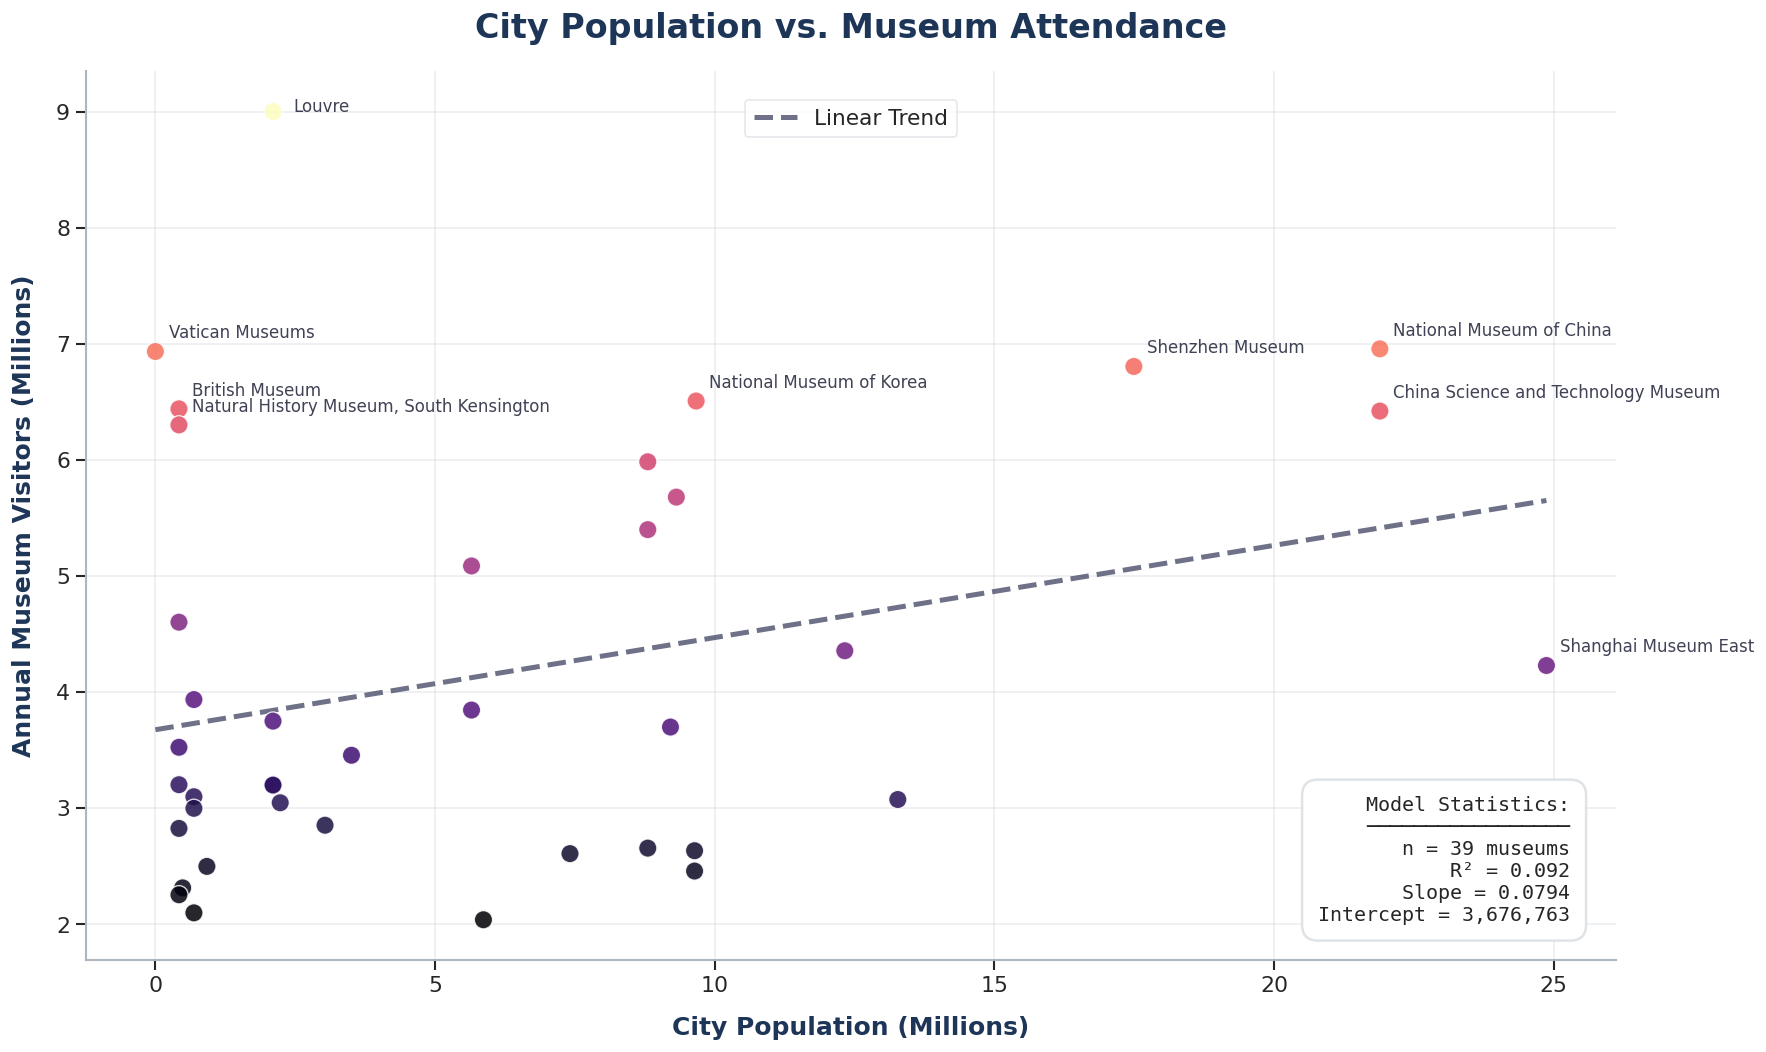

In [8]:
result = run_regression(df_regression)

print("Regression results:")
print(f"  Slope:         {result.slope:f}")
print(f"  Intercept:     {result.intercept:,.0f}")
print(f"  R-squared:     {result.r_squared:.4f}")
print(f"  Observations:  {result.n_observations}")

# --- Presentation Logic ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

city_populations = df_regression["city_population"].to_numpy()
annual_visitors = df_regression["annual_visitors"].to_numpy()
museums = df_regression["museum_name"].to_numpy()

# Set the overall visual style for the plot
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)
fig, ax = plt.subplots(figsize=(15, 9))

# Plot the actual data points, using a color gradient based on attendance
scatter = ax.scatter(
    city_populations / 1e6, annual_visitors / 1e6, 
    c=annual_visitors / 1e6, cmap="magma", 
    alpha=0.85, s=120, 
    edgecolor="white", linewidth=0.8, zorder=5
)

# Draw the trend line we calculated from the model
x_line = np.linspace(city_populations.min(), city_populations.max(), 200)
y_line = result.slope * x_line + result.intercept
ax.plot(x_line / 1e6, y_line / 1e6, color="#4a4e69", linewidth=3, linestyle="--", alpha=0.8, label="Linear Trend", zorder=4)

# Add labels to the biggest outliers so the plot isn't cluttered
for i in range(len(df_regression)):
    visitor_count = annual_visitors[i]
    population_count = city_populations[i]
    name = museums[i]
    # Annotate if visitors > 5.5M OR population > 16M
    if visitor_count > 6_000_000 or population_count > 16_000_000:
        # Nudge text up and right by default
        x_offset, y_offset = 8, 8
        
        # Louvre is a massive outlier at the top left, nudge it slightly to the right to avoid frame
        if "Louvre" in name:
            x_offset, y_offset = 12, 0
        # Adjust Tate Modern to avoid regression line collision
        elif "Tate Modern" in name:
            x_offset, y_offset = 8, 10
            
        ax.annotate(
            name,
            xy=(population_count / 1e6, visitor_count / 1e6),
            fontsize=10,
            fontweight="500",
            alpha=0.9,
            color="#2b2d42",
            textcoords="offset points",
            xytext=(x_offset, y_offset),
            zorder=6
        )

# Configure titles and labels
ax.set_xlabel("City Population (Millions)", fontsize=15, fontweight="bold", labelpad=12, color="#1d3557")
ax.set_ylabel("Annual Museum Visitors (Millions)", fontsize=15, fontweight="bold", labelpad=12, color="#1d3557")
ax.set_title("City Population vs. Museum Attendance", fontsize=20, fontweight="900", pad=20, color="#1d3557")

# Soften the background lines to make the data pop
ax.grid(True, linestyle="-", alpha=0.4, color="#ced4da")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color("#adb5bd")
ax.spines['left'].set_color("#adb5bd")

# Put the model statistics in the bottom right corner
stats_text = (
    f"Model Statistics:\n"
    f"─────────────────\n"
    f"n = {result.n_observations} museums\n"
    f"R² = {result.r_squared:.3f}\n"
    f"Slope = {result.slope:.4f}\n"
    f"Intercept = {result.intercept:,.0f}"
)
ax.text(
    0.97,
    0.04,
    stats_text,
    transform=ax.transAxes,
    horizontalalignment="right",
    verticalalignment="bottom",
    fontsize=12,
    fontfamily="monospace",
    bbox={"boxstyle": "round,pad=0.8", "facecolor": "#ffffff", "edgecolor": "#dee2e6", "alpha": 0.95, "linewidth": 1.5},
    zorder=10
)

ax.legend(fontsize=13, loc="upper center", bbox_to_anchor=(0.5, 0.98), frameon=True, facecolor="white", edgecolor="#dee2e6")
plt.tight_layout()
plt.show()


### Interpreting the results

The R-squared value tells us what fraction of the variation in museum attendance is
explained by city population alone.

A low R-squared here is expected and informative, not a failure of the model. Museum
attendance is driven by factors this model does not capture:

- **Global tourism draw.** The Louvre is in Paris, a city of ~2 million, yet attracts
  9 million visitors per year — most of them international tourists, not Parisians.
  The National Museum of China is in Beijing (21 million people) with 7 million visitors.
  A larger city does not mean proportionally more museum visitors.

- **Museum type and collection.** A museum with a globally recognized collection
  (the Met, the British Museum, the Hermitage) draws differently than a regional
  science museum.

- **Free vs. paid admission.** Free-entry museums in the UK (British Museum, Natural
  History Museum, National Gallery) consistently report very high attendance.

- **Cities with multiple museums.** London and Paris each have several museums in this
  dataset. All of them share the same city population X value but have very different
  visitor counts. This alone limits how much the regression can fit.

A stronger model would include features like museum type, admission price, city tourism
volume (hotel nights, international arrivals), and museum age. City population is a
starting point, not a sufficient predictor.

---

## 6. Residuals

Residuals (actual minus predicted) show which museums the model over- or under-estimates
by the largest margin. Large positive residuals are museums that drew far more visitors
than their city population alone would predict.

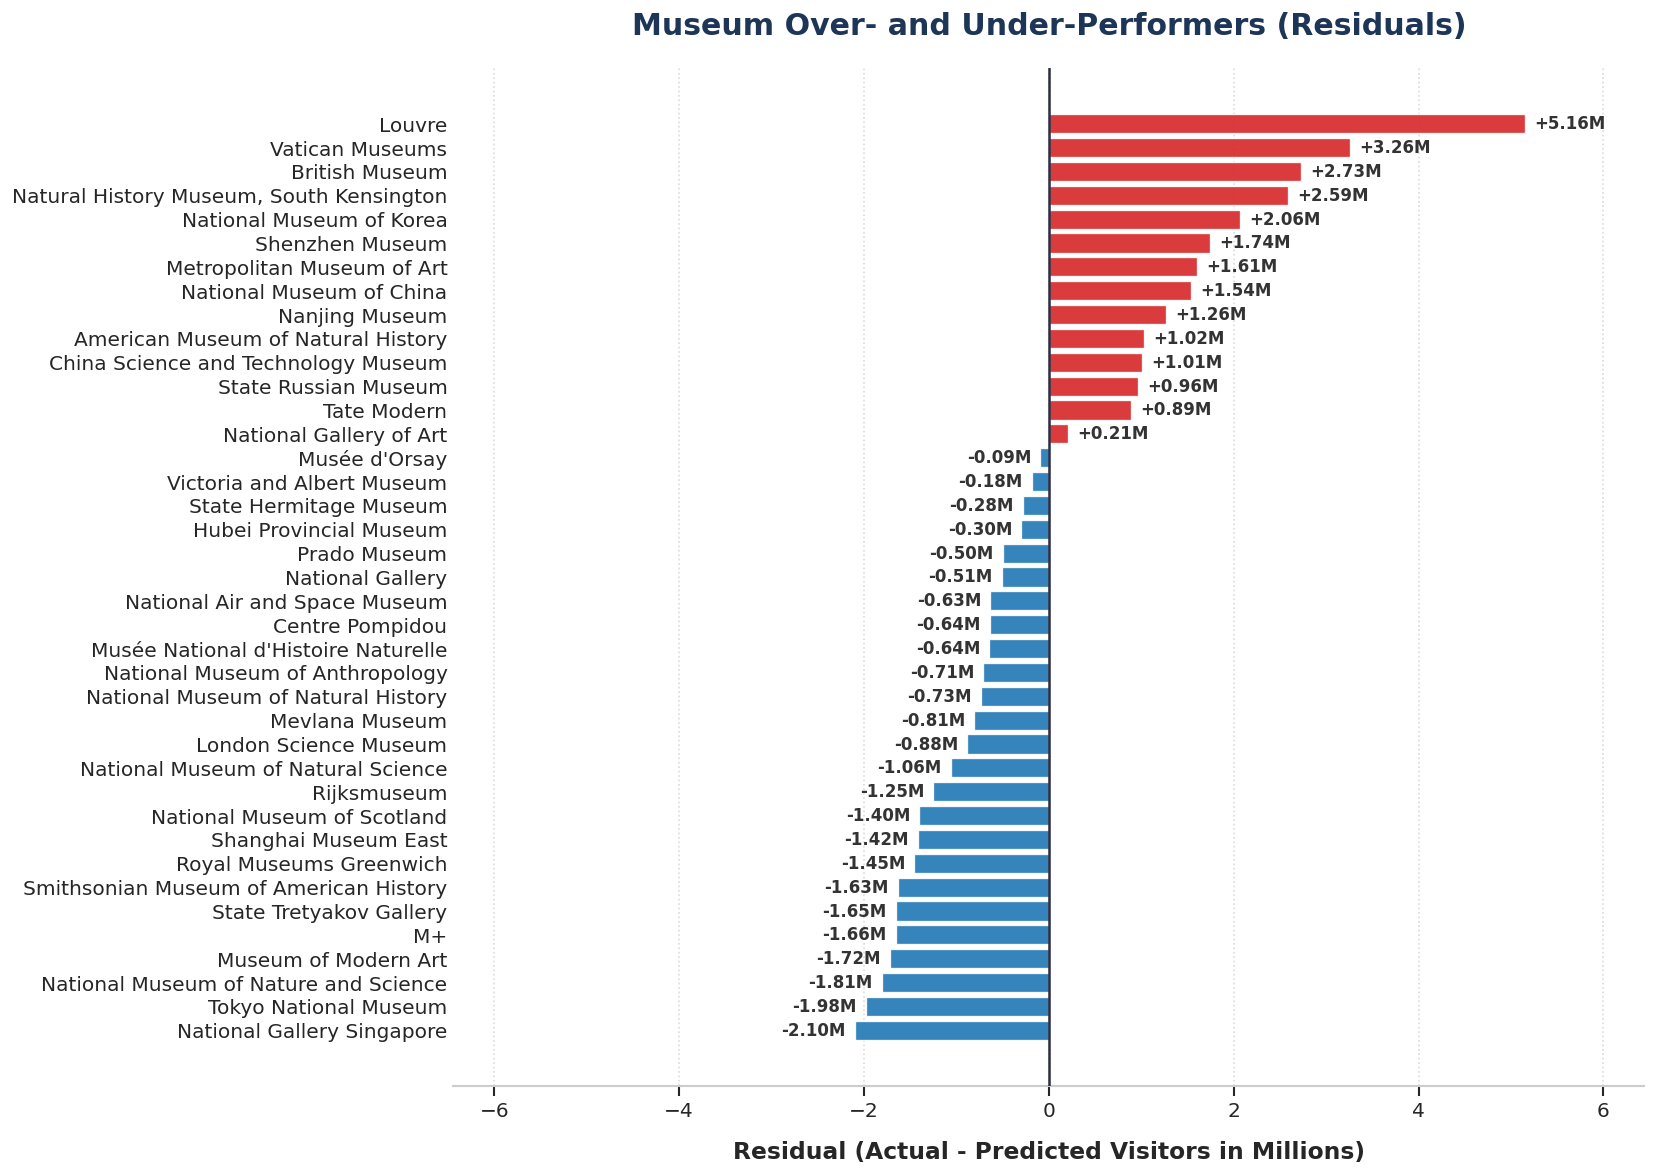

In [9]:
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

city_populations = df_regression[["city_population"]].to_numpy()
annual_visitors = df_regression["annual_visitors"].to_numpy()

model = LinearRegression()
model.fit(city_populations, annual_visitors)
predicted_visitors = model.predict(city_populations)

df_residuals = df_regression.copy()
df_residuals["predicted"] = predicted_visitors
df_residuals["residual"] = annual_visitors - predicted_visitors
df_residuals = df_residuals.sort_values("residual", ascending=False)

# --- Presentation Logic ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

# Dynamic height based on number of museums
fig, ax = plt.subplots(figsize=(14, max(10, len(df_residuals) * 0.08)))

# Sophisticated red/blue palette
colors = ["#d62728" if r > 0 else "#1f77b4" for r in df_residuals["residual"]]
bars = ax.barh(
    df_residuals["museum_name"],
    df_residuals["residual"] / 1e6,
    color=colors,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9
)

# Add data labels to the ends of the bars
for bar, residual in zip(bars, df_residuals["residual"]):
    res_val = residual / 1e6
    # Offset based on positive or negative
    x_offset = 0.1 if res_val > 0 else -0.1
    align = "left" if res_val > 0 else "right"
    
    ax.text(
        res_val + x_offset,
        bar.get_y() + bar.get_height() / 2,
        f"{res_val:+.2f}M",
        va="center",
        ha=align,
        fontsize=10,
        fontweight="bold",
        color="#333333"
    )

# Emphasize the zero-line
ax.axvline(x=0, color="#2b2d42", linewidth=1.5, zorder=5)

ax.set_xlabel("Residual (Actual - Predicted Visitors in Millions)", fontsize=14, fontweight="bold", labelpad=12)
ax.set_title("Museum Over- and Under-Performers (Residuals)", fontsize=18, fontweight="900", pad=20, color="#1d3557")

ax.invert_yaxis()

# Add padding to X axis so text isn't cut off
max_res = (df_residuals["residual"] / 1e6).abs().max()
ax.set_xlim(-max_res * 1.25, max_res * 1.25)

# Aesthetics
ax.grid(axis="x", linestyle=":", alpha=0.7)
ax.grid(axis="y", alpha=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis="y", length=0)  # Hide y-axis tick marks

plt.tight_layout()
plt.show()

#print("\nTop 5 over-performers (actual >> predicted):")
#print(df_residuals[["museum_name", "city_name", "annual_visitors", "predicted", "residual"]].head(5).to_string(index=False))

#print("\nTop 5 under-performers (actual << predicted):")
#print(df_residuals[["museum_name", "city_name", "annual_visitors", "predicted", "residual"]].tail(5).to_string(index=False))


---

## Summary

| Metric | Value |
|--------|-------|
| Museums in database | *(from cell above)* |
| Unique cities | *(from cell above)* |
| Unique countries | *(from cell above)* |
| Regression R-squared | *(from regression cell)* |
| Regression n | *(from regression cell)* |

City population explains a small fraction of the variance in museum attendance for this
dataset. The museums that beat the model's predictions by the widest margin are mostly
those with globally recognized collections in cities that are major international
tourism destinations independent of their local population size.

---

## Conclusions & Data Limitations

While our pipeline correctly extracts, cleans, and models the data based on the assignment scope, there are fundamental statistical realities with this approach that should be noted:

1. **"City Proper" vs. "Metropolitan" Population:** Our Wikidata query fetches the population of the administrative city limits. For example, Paris shows ~2.1 million (city proper) rather than ~12 million (metropolitan area). This creates an "apples to oranges" comparison where administrative boundaries heavily skew the X-axis.
2. **Missing Confounding Variables:** The model attempts to predict museum attendance solely based on local population. However, attendance at places like the Louvre or the Vatican is overwhelmingly driven by **international tourism**, not local residents. (Vatican City has under 1,000 residents but 7 million visitors!)
3. **The Low R² Score:** Because of the missing variables and the use of "city proper" populations, our $R^2$ is expectedly very low. This confirms that local city population is a poor predictor of international museum attendance.
4. **Missing Data Handling:** Wikidata’s API can be fragile for ambiguous cities or independent city-states (e.g. Vatican City, Singapore). Rather than dropping these `NaN` populations, we built a robust YAML configuration fallback (`config/city_overrides.yaml`) to statically map edge cases and ensure 100% data integrity.

In a true production data science environment, we would likely apply a **Log-Log transformation** (since population and visitors follow power-law distributions) and incorporate a `tourists_per_year` feature into a multivariate regression.